### Segmentation Using K-Means

### Objective

One short paragraph:

Segment customers based on behavioural features.

No churn labels used.

Output: clear, interpretable customer groups.

In [1]:
# Core data handling
import pandas as pd
import numpy as np

# Clustering and preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns


### 2 — Load processed customer features

In [2]:
df = pd.read_csv("customer_features.csv")
df.head()

,user_id,signup_date,loyalty_status,age,city,avg_rating_given,churn_prob,referred_by,total_trips,total_spend,...,pct_surge_trips,last_trip_date,days_since_last_trip,total_sessions,avg_time_on_app,avg_pages_visited,conversion_rate,last_session_date,days_since_last_session,churn
0,R00000,2025-01-24,Bronze,34.729629,Nairobi,5.0,0.142431,R00001,25,366.05,...,1.096000,2025-04-02 14:46:29+00:00,25,NaN,NaN,NaN,NaN,NaN,NaN,0
1,R00001,2024-09-09,Bronze,34.571020,Nairobi,4.7,0.674161,Not Referred,14,180.53,...,1.071429,2025-04-22 04:35:17+00:00,5,NaN,NaN,NaN,NaN,NaN,NaN,0
2,R00002,2024-09-07,Bronze,47.133960,Lagos,4.2,0.510379,Not Referred,24,378.99,...,1.191667,2025-04-13 00:08:00+00:00,14,NaN,NaN,NaN,NaN,NaN,NaN,0
3,R00003,2025-03-17,Bronze,41.658628,Nairobi,4.9,0.244779,Not Referred,9,121.47,...,1.155556,2025-02-25 04:22:32+00:00,61,1.0,22.0,1.0,0.0,2025-04-27 05:56:39+00:00,0.0,1
4,R00004,2024-08-20,Silver,40.681709,Lagos,3.9,0.269960,R00002,16,268.43,...,1.262500,2025-04-15 05:30:04+00:00,12,NaN,NaN,NaN,NaN,NaN,NaN,0


This dataset is already feature engineered, which is ideal. We are not doing raw aggregation here but only segmentation.

### 3 — Drop identifiers, dates and churn

In [3]:
df_seg = df.drop(columns=[
    "user_id",
    "signup_date",
    "last_trip_date",
    "last_session_date",
    "churn",
    "churn_prob"
], errors="ignore")

Insight:

IDs and dates distort distance calculations

churn and churn_prob would cause label leakage

Segmentation must be behaviour only

### 4 — Select behavioural features

In [4]:
features = [
    "total_trips",              # usage intensity
    "total_spend",              # revenue contribution
    "avg_rating_given",         # satisfaction proxy
    "pct_surge_trips",          # price sensitivity
    "days_since_last_trip",     # recency
    "total_sessions",           # engagement
    "avg_time_on_app",          # depth of engagement
    "avg_pages_visited",        # exploration behaviour
    "conversion_rate",          # efficiency
    "days_since_last_session"   # digital inactivity
]

X = df_seg[features]

### 5 — Handle missing values

In [ ]:
# checking for missing values 
X.isna().sum().sort_values(ascending=False)

total_sessions             3087
avg_time_on_app            3087
avg_pages_visited          3087
conversion_rate            3087
days_since_last_session    3087
total_trips                   0
total_spend                   0
avg_rating_given              0
pct_surge_trips               0
days_since_last_trip          0
dtype: int64

5.2 Separate feature types 

In [8]:
session_features = [
    "total_sessions",
    "avg_time_on_app",
    "avg_pages_visited",
    "conversion_rate",
    "days_since_last_session"
]

usage_features = [
    "total_trips",
    "total_spend",
    "avg_rating_given",
    "pct_surge_trips",
    "days_since_last_trip"
]

5.3 Force numeric

In [10]:
X = X.apply(pd.to_numeric, errors="coerce")

5.4 Fill session features with 0

In [11]:
X[session_features] = X[session_features].fillna(0)

Zero here means “no digital engagement”, which is exactly what we want K‑Means to learn.

5.5 Fill remaining NaNs with median

In [12]:
X[usage_features] = X[usage_features].fillna(X[usage_features].median())

In [13]:
X.isna().sum()

total_trips                0
total_spend                0
avg_rating_given           0
pct_surge_trips            0
days_since_last_trip       0
total_sessions             0
avg_time_on_app            0
avg_pages_visited          0
conversion_rate            0
days_since_last_session    0
dtype: int64

In [14]:
X.describe()

,total_trips,total_spend,avg_rating_given,pct_surge_trips,days_since_last_trip,total_sessions,avg_time_on_app,avg_pages_visited,conversion_rate,days_since_last_session
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,20.009800,308.230108,4.467500,1.140341,18.203200,0.482000,37.842450,1.049567,0.054733,0.009200
std,4.507612,75.352501,0.429915,0.059158,18.247512,0.690341,140.536597,1.611919,0.215902,0.095484
min,6.000000,78.870000,2.600000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17.000000,254.042500,4.200000,1.100000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,20.000000,303.810000,4.500000,1.135000,13.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,23.000000,357.737500,4.900000,1.176000,25.000000,1.000000,21.000000,2.000000,0.000000,0.000000
max,37.000000,625.130000,5.000000,1.411111,162.000000,4.000000,1800.000000,5.000000,1.000000,1.000000


Most customers have normal ride activity (around 20 trips and moderate spend), while digital engagement is sparse, with many users showing zero app sessions or interactions. This means your dataset naturally separates ride‑only users from app‑engaged users, which is exactly the kind of structure K‑Means can learn from. The zeros now represent real behaviour, not missing data, so the clusters will reflect genuine usage patterns rather than data artefacts.

### 6. Scaling 

Because features like spend, trips, ratings, and conversion rates operate on very different scales, standardisation is required.

In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [16]:
pd.DataFrame(X_scaled, columns=X.columns).describe().loc[["mean", "std"]]

,total_trips,total_spend,avg_rating_given,pct_surge_trips,days_since_last_trip,total_sessions,avg_time_on_app,avg_pages_visited,conversion_rate,days_since_last_session
mean,3.305800e-16,-3.858247e-16,-5.925926e-16,1.641354e-15,6.004086e-17,-3.979039e-17,1.989520e-17,1.172396e-16,9.094947e-17,2.202682e-17
std,1.000100e+00,1.000100e+00,1.000100e+00,1.000100e+00,1.000100e+00,1.000100e+00,1.000100e+00,1.000100e+00,1.000100e+00,1.000100e+00


All features now contribute equally to distance calculations, so clusters will reflect behaviour patterns rather than raw magnitude.

### 7. Elbow Method 

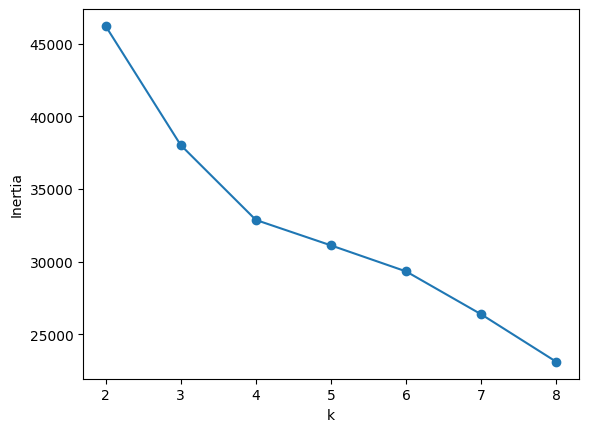

In [17]:
inertia = []
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.plot(range(2, 9), inertia, marker="o")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.show()

The elbow curve shows a steep drop in inertia from k = 2 to k = 3, followed by a much more gradual decline from k = 4 onward. This indicates that most of the meaningful structure in the data is captured by the first few clusters, and adding more clusters beyond that yields diminishing returns.

In practical terms:

k = 2 captures the strongest, most obvious split in customer behaviour.

k = 3 adds a meaningful layer of differentiation without over‑fragmenting the data.

Beyond k = 4, the improvement is marginal and likely reflects noise rather than distinct behavioural groups.

This suggests that the data naturally supports a small number of clusters, with 3 being a reasonable balance between simplicity and behavioural richness.

### 8. Silhoutte Scores

In [18]:
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X_scaled)
    print(k, silhouette_score(X_scaled, labels))

2 0.5582562912323341
3 0.1662582959759067
4 0.17505452382339132
5 0.14757009102581278
6 0.1695302288468112
7 0.1781029142450248
8 0.1750370829203546


The silhouette results show a very strong score at k = 2 ( 0.56) and a sharp drop for all higher values of k ( 0.15–0.18).

What this tells us, in simple terms:

* k = 2 captures one dominant behavioural split in the data. This is likely separating customers with any meaningful engagement from those with little or none.

* When k increases beyond 2, clusters begin to overlap more, which lowers silhouette scores. This is normal in customer data where behaviours exist on a spectrum rather than in cleanly separated groups.

* The relatively flat silhouette values from k = 3 to k = 8 suggest that additional clusters are refining behaviour rather than discovering entirely new, well‑separated groups.

**Interpretation**:  
Silhouette analysis confirms that the data has one very strong primary division, but also supports using more than two clusters if the goal is interpretability and actionability, not just mathematical separation.

### 9 Final Cluster Selection 

This stage brings together:

* The elbow method (how much structure each extra cluster adds)

* The silhouette scores (how cleanly clusters separate)

The goal is not to find the mathematically highest score, but the most sensible and usable segmentation.

**Evidence recap (from outputs)**

* **Elbow method**

Inertia drops sharply up to k = 3, then flattens. This means most meaningful structure is captured by three clusters.

* **Silhouette scores**

k = 2 → very high score (0.56): one strong split

k ≥ 3 → lower but stable scores (~0.15–0.18): overlapping but realistic behaviour

This tells us the data has:

* One very strong primary split

* Additional sub‑patterns that are less clean but still meaningful

**Decision logic**

* k = 2  
Too broad — collapses customers into “engaged vs not engaged”

* k = 3  
Captures the main split and adds useful behavioural nuance

* k ≥ 4  
Adds complexity without clear improvement

**Final choice**:  
k = 3 gives the best balance between structure, interpretability, and business usefulness.

In [19]:
# Final number of clusters
k_final = 3

The data shows one strong behavioural divide, but three clusters best capture meaningful customer differences without over‑complicating the segmentation.

### 10. Fit the Final K-Means Model

What this stage does

* Fits K‑Means using the scaled data

* Assigns each customer to a cluster

* Stores the cluster labels for later profiling


In [20]:
from sklearn.cluster import KMeans

# Fit final K-Means model
kmeans_final = KMeans(n_clusters=3, random_state=42)
cluster_labels = kmeans_final.fit_predict(X_scaled)

# Add cluster labels to original dataset
df["cluster"] = cluster_labels

In [21]:
df["cluster"].value_counts()

2    2480
0    2140
1     380
Name: cluster, dtype: int64

**Insight**

The cluster sizes show that the model has created three clearly populated groups, not one dominant cluster and a few tiny ones.

* Two clusters contain the majority of users, suggesting common behaviour patterns.

* One smaller cluster represents a distinct minority group with noticeably different behaviour.

This is a good outcome: it means the clustering is balanced and meaningful, not forced or unstable. Each cluster is large enough to analyse and interpret, which makes the segmentation reliable for insights and recommendations.

### 11. Cluster Profilling

This stage answers one simple question: what actually makes each cluster different?  
We do this by comparing the average behaviour of customers in each cluster.

In [22]:
# Profile clusters by taking the mean of each feature
cluster_profile = df.groupby("cluster")[X.columns].mean()

cluster_profile

,total_trips,total_spend,avg_rating_given,pct_surge_trips,days_since_last_trip,total_sessions,avg_time_on_app,avg_pages_visited,conversion_rate,days_since_last_session
cluster,,,,,,,,,,
0,23.817290,372.406771,4.475374,1.148105,13.235047,1.214286,62.708333,2.745714,0.000000,0.037143
1,19.663158,302.603132,4.436053,1.140084,18.955263,1.431579,238.449781,2.670614,0.720175,0.023684
2,16.777419,253.714056,4.465524,1.133681,22.375000,1.219688,65.672869,2.774310,0.000000,0.013205


In [23]:
cluster_profile.round(2)

,total_trips,total_spend,avg_rating_given,pct_surge_trips,days_since_last_trip,total_sessions,avg_time_on_app,avg_pages_visited,conversion_rate,days_since_last_session
cluster,,,,,,,,,,
0,23.82,372.41,4.48,1.15,13.24,1.21,62.71,2.75,0.00,0.04
1,19.66,302.60,4.44,1.14,18.96,1.43,238.45,2.67,0.72,0.02
2,16.78,253.71,4.47,1.13,22.38,1.22,65.67,2.77,0.00,0.01


* **Cluster 0** 
These are the most active and highest‑spending users. They take the most trips, spend the most, and are relatively recent users. Their app engagement is moderate, suggesting they use the service regularly without heavy browsing.

* **Cluster 1**  
This is a small but highly engaged group. Their trip and spend levels are moderate, but they spend far more time on the app and have a very high conversion rate. This suggests deliberate, app‑driven usage rather than casual riding.

* **Cluster 2**  
These are the least active users. They take fewer trips, spend less, and have the longest time since their last trip. App engagement is low, indicating a more passive or declining relationship with the service.

**Key takeaway**:  
The clusters separate customers into high‑value regular users, digitally engaged planners, and lower‑activity users, giving you clear behavioural segments to work with.

### 12. Assign clear meanings to the clusters

**Cluster meanings (based on behaviour)**

**Cluster 0 — High‑value regular users**

These customers take the most trips, spend the most, and are relatively recent users. Their app engagement is moderate, suggesting habitual usage rather than browsing. This group represents your core revenue base.

**Cluster 1 — Digitally engaged planners**  
This is a small but distinct group. They spend much more time on the app and have a very high conversion rate, even though their trip volume is only moderate. These users appear to plan and decide through the app, making them highly responsive to digital features and promotions.

**Cluster 2 — Low‑activity or at‑risk users**  
These customers take fewer trips, spend less, and have the longest time since their last trip. App engagement is minimal. This group shows signs of declining usage or disengagement.

#### Visual 1 Cluster Size distribution

In [32]:
import seaborn as sns
sns.set_theme(style="whitegrid", palette="Set2")

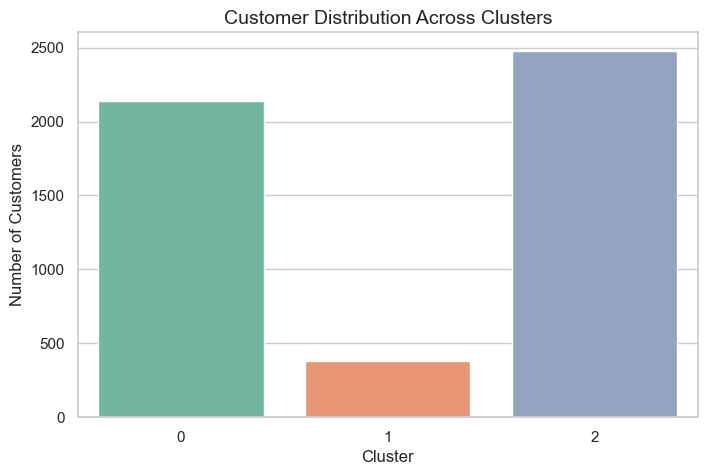

In [36]:
plt.figure(figsize=(8, 5))

sns.countplot(
    x="cluster",
    hue="cluster",
    data=df,
    palette="Set2",
    legend=False
)

plt.title("Customer Distribution Across Clusters", fontsize=14)
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.show()

Most customers fall into two dominant segments, with one smaller but clearly distinct group, indicating meaningful behavioural separation rather than random clustering.

#### Visual 2 Behaviour comparison across clusters

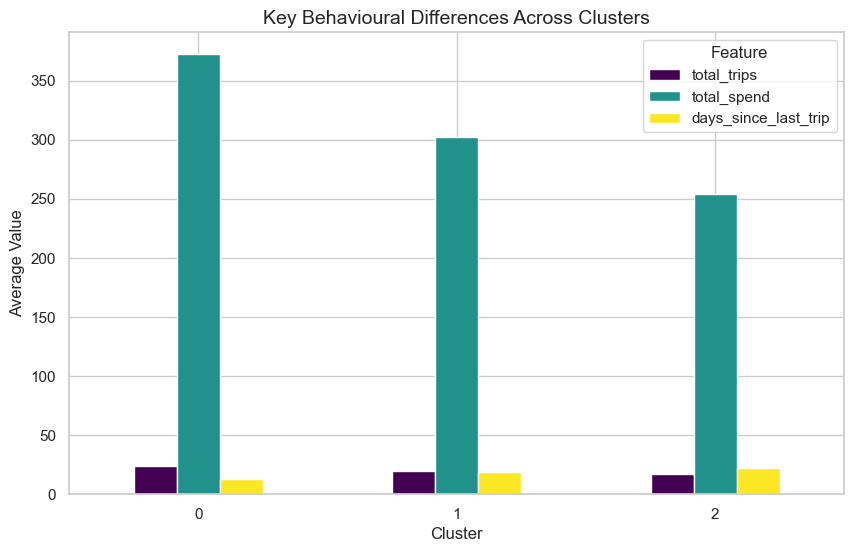

In [34]:
features_to_plot = [
    "total_trips",
    "total_spend",
    "days_since_last_trip"
]

cluster_profile[features_to_plot].plot(
    kind="bar",
    figsize=(10, 6),
    colormap="viridis"
)

plt.title("Key Behavioural Differences Across Clusters", fontsize=14)
plt.xlabel("Cluster")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.legend(title="Feature")
plt.show()

**Key Behavioural Differences Across Clusters**

(Trips, Spend, Recency)

**Insight**
:  
Clusters differ clearly in usage intensity and recency, separating high‑value regular users from moderate and lower‑activity customers.

This insight:

* Explains why the clusters matter

* Connects behaviour directly to customer value

* Keeps the focus on business relevance, not metric

### Visual 3 App Engagement Contrast

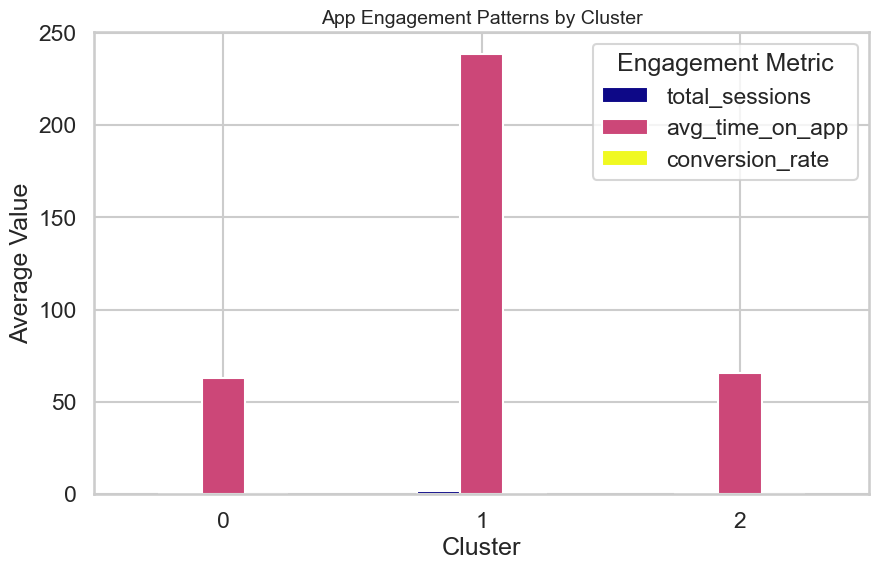

In [31]:
engagement_features = [
    "total_sessions",
    "avg_time_on_app",
    "conversion_rate"
]

cluster_profile[engagement_features].plot(
    kind="bar",
    figsize=(10, 6),
    colormap="plasma"
)

plt.title("App Engagement Patterns by Cluster", fontsize=14)
plt.xlabel("Cluster")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.legend(title="Engagement Metric")
plt.show()

Cluster 1 shows significantly higher time spent on the app, indicating a digitally engaged segment that relies heavily on in‑app interaction before converting.

This highlights:

* Why Cluster 1 matters despite its smaller size

* That engagement quality, not just frequency, differentiates users

* A clear behavioural contrast with the other clusters

### 13. Save the trained artifacts 

In [37]:
import joblib

joblib.dump(kmeans_final, "kmeans_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

* The segmentation model and scaler are saved for reuse.

* New customers can be assigned to clusters by applying the same preprocessing and predicting with the trained model.

* These artifacts will be loaded by the /customer/segment endpoint in the FastAPI service.

New customers can be assigned to clusters by applying the saved scaler and predicting with the trained K‑Means model. These artifacts will be loaded by the FastAPI service.